In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# target: 0 = Malignant, 1 = Benign
# Quick sanity check
print(f"Dataset shape : {X.shape}")          # (569, 30)
print(f"Feature count : {len(data.feature_names)}")
print(f"Class balance : Malignant={sum(y==0)}, Benign={sum(y==1)}")
print(f"\nSample features: {data.feature_names[:5]}")

Dataset shape : (569, 30)
Feature count : 30
Class balance : Malignant=212, Benign=357

Sample features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42,    # reproducibility — same split every run
    stratify=y          # preserves class ratio in both splits
)

print(f"Train size : {X_train.shape[0]} samples")
print(f"Test size  : {X_test.shape[0]} samples")

Train size : 455 samples
Test size  : 114 samples


In [3]:
from sklearn.tree import DecisionTreeClassifier

# Deliberately unconstrained — we WANT to see the overfitting
# This mirrors what Stage 4 will fix
dt_unconstrained = DecisionTreeClassifier(
    criterion='gini',      # splitting metric (our Stage 1 math)
    random_state=42        # for reproducibility
    # No max_depth — the tree will grow until all leaves are pure
)

dt_unconstrained.fit(X_train, y_train)

print(f"Tree depth (unconstrained) : {dt_unconstrained.get_depth()}")
print(f"Total leaf nodes           : {dt_unconstrained.get_n_leaves()}")


Tree depth (unconstrained) : 7
Total leaf nodes           : 19


In [4]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = dt_unconstrained.predict(X_test)

print("=" * 55)
print("       CLASSIFICATION REPORT — Unconstrained Tree")
print("=" * 55)
print(classification_report(
    y_test, y_pred,
    target_names=['Malignant (0)', 'Benign (1)']
))

# Confusion Matrix for visual clarity
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(f"              Predicted Mal  Predicted Ben")
print(f"Actual Mal        {cm[0][0]}              {cm[0][1]}")
print(f"Actual Ben        {cm[1][0]}             {cm[1][1]}")

       CLASSIFICATION REPORT — Unconstrained Tree
               precision    recall  f1-score   support

Malignant (0)       0.85      0.93      0.89        42
   Benign (1)       0.96      0.90      0.93        72

     accuracy                           0.91       114
    macro avg       0.90      0.92      0.91       114
 weighted avg       0.92      0.91      0.91       114

Confusion Matrix:
              Predicted Mal  Predicted Ben
Actual Mal        39              3
Actual Ben        7             65


In [5]:
from sklearn.tree import export_text

# Constrained to depth 3 for readable output
dt_display = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    random_state=42
)
dt_display.fit(X_train, y_train)

rules = export_text(
    dt_display,
    feature_names=list(data.feature_names)
)
print(rules)

|--- worst radius <= 16.80
|   |--- worst concave points <= 0.14
|   |   |--- area error <= 91.56
|   |   |   |--- class: 1
|   |   |--- area error >  91.56
|   |   |   |--- class: 0
|   |--- worst concave points >  0.14
|   |   |--- worst texture <= 25.62
|   |   |   |--- class: 1
|   |   |--- worst texture >  25.62
|   |   |   |--- class: 0
|--- worst radius >  16.80
|   |--- texture error <= 0.47
|   |   |--- class: 1
|   |--- texture error >  0.47
|   |   |--- worst concavity <= 0.19
|   |   |   |--- class: 1
|   |   |--- worst concavity >  0.19
|   |   |   |--- class: 0



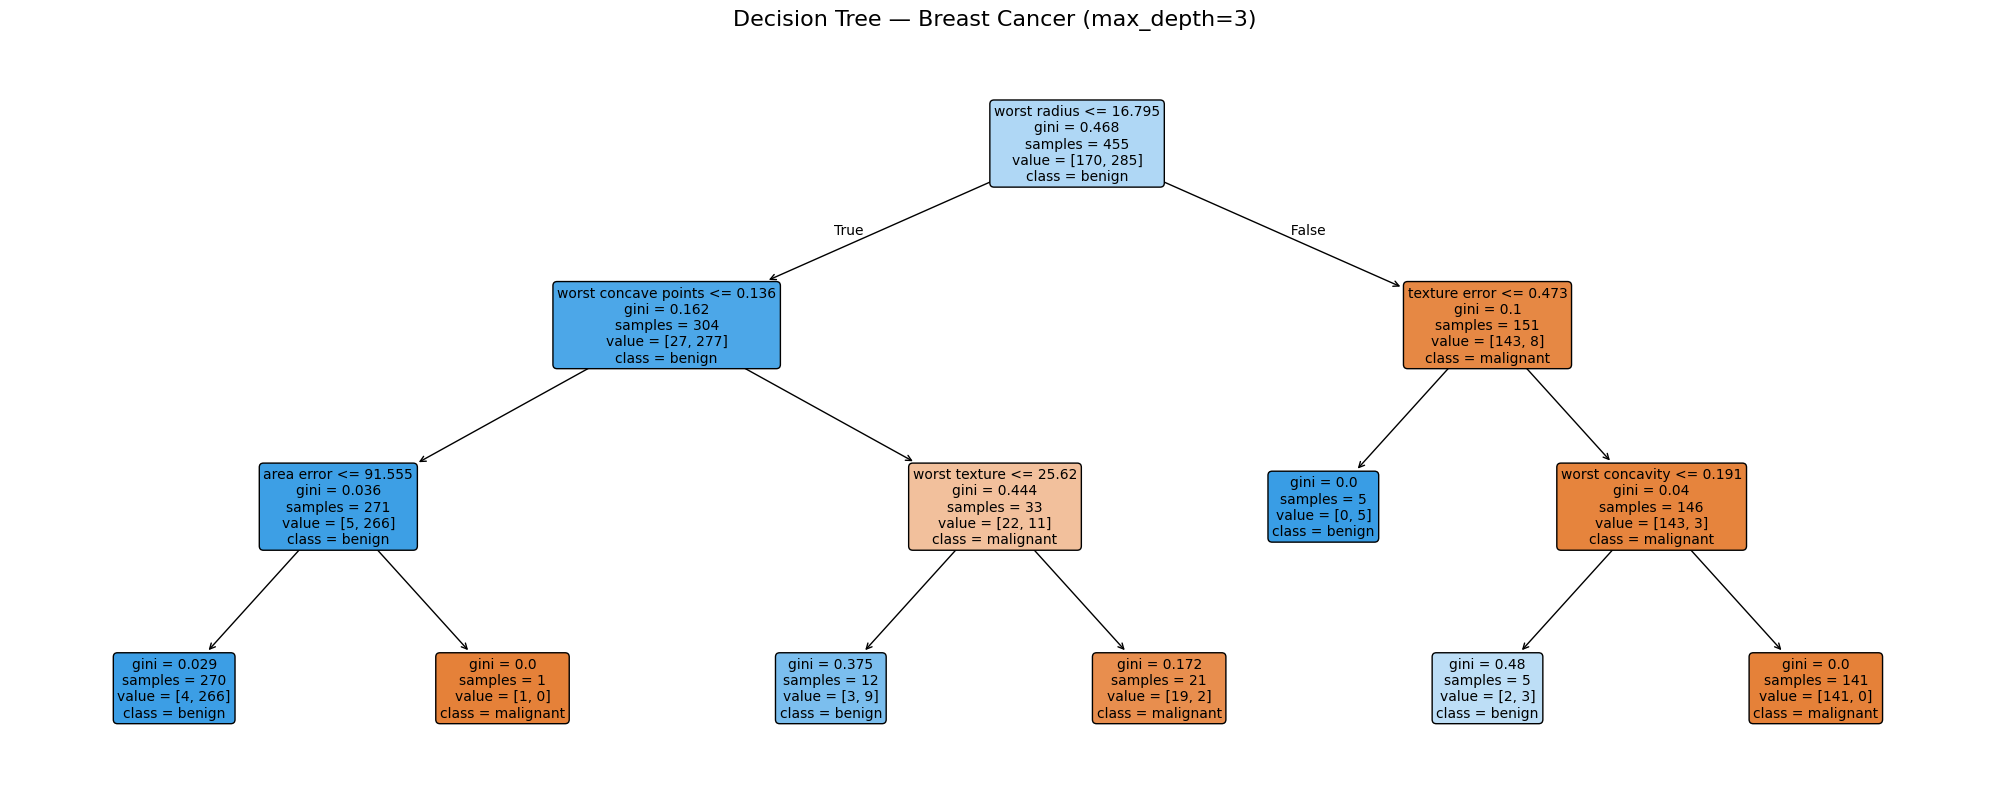

In [6]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(20, 8))

plot_tree(
    dt_display,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,          # color nodes by majority class
    rounded=True,         # cosmetic: rounded boxes
    fontsize=10,
    ax=ax,
    impurity=True,        # shows Gini at each node — ties back to Stage 1
    proportion=False      # shows raw sample counts, not proportions
)

plt.title("Decision Tree — Breast Cancer (max_depth=3)", fontsize=16, pad=20)
plt.tight_layout()
plt.savefig("decision_tree_stage3.png", dpi=150, bbox_inches='tight')
plt.show()